In [1]:
#%%
from attack_utils import *
from matplotlib import pyplot as plt

In [ ]:
which_dataset = 4    # 'iris = 0', 'crop = 1', 'adult = 2', 'breast = 3', 'nursery = 4', 'mushroom = 5', 'bc-tcga = 6', 'digits = 7'
which_model = 1    # 'Decision_Tree = 0', 'Logistic_Regression = 1', 'Multinomial_Naive_Bayes = 2', 'K_Nearest_Neeighbor = 3', 'Random_Forest = 4', 'Multilayer_Perceptron = 5'
explanation_tool = 1 # 'Lime = 0', 'Shap = 1'
how_many_sets = 10 # This is the number of auxiliary datasets to experiment on. Lower the number for lowering the runtime.
sample_set_sizes = [5] # (list of n values from the paper) Size of auxiliary dataset (per class) in a list format
nfe = [3] # (list of k values from the paper) Number of features explored in a list format
query_limit = [500] # (list of Q values from the paper) Number of queries allowed for traversal

In [3]:
## Shorten nfe for shorter runtime
results, other_args = run_attack_auto_v2(which_dataset, which_model, explanation_tool, how_many_sets, sample_set_sizes, nfe, query_limit, False, 5)

Train results
[[3228    0    0]
 [  50 3022  126]
 [  49  160 3085]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3228
           1       0.95      0.94      0.95      3198
           2       0.96      0.94      0.95      3294

    accuracy                           0.96      9720
   macro avg       0.96      0.96      0.96      9720
weighted avg       0.96      0.96      0.96      9720

Test results
[[634   0   0]
 [ 22 546  77]
 [ 25  78 562]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       634
           1       0.88      0.85      0.86       645
           2       0.88      0.85      0.86       665

    accuracy                           0.90      1944
   macro avg       0.90      0.90      0.90      1944
weighted avg       0.89      0.90      0.89      1944

Model test accuracy:  0.8961 



Dataset:   Nursery
ML Model:  K Nearest Neighbor
SHAP is the explanation tool currently in use

Lower bounds:  [84]  Upper bounds:  [582] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 2 \Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
216 216
Average confidence score for samples classified differently by surrogate model: 0.8158000806126551
Average confidence score for samples classified same by surrogate model: 0.8492987168009483
Sample set 0 , n_queries = 216 , Similarities by type:

Processing sample set 1
Processing explanation type: vanilla
1 2 \Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
309 309
Average confidence score for samples classified differently by surrogate model: 0.8245614035087698
Avera

In [4]:
#print average similaties and accuracies for each explanation type and standard deviations
for etype in results:
    print(f"Explanation Type: {etype}")
    # print("Average Accuracy and Std Dev: ", np.mean(results[etype]['accuracies']), np.std(results[etype]['accuracies']))
    print("Average Similarity and Std Dev: ", np.mean(results[etype]['rtest_sims']), np.std(results[etype]['rtest_sims']))
    print()

Explanation Type: vanilla
Average Similarity and Std Dev:  0.56456 0.03149041759011778



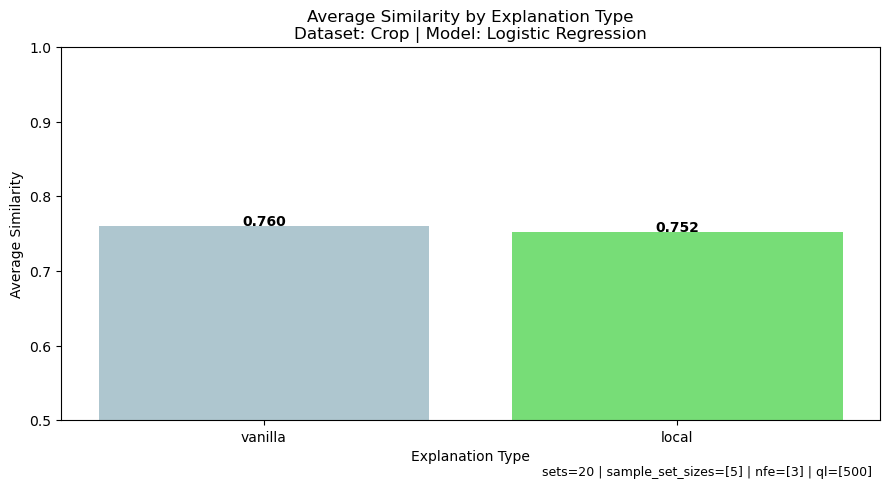

In [ ]:
# visualize results x axis is the explanation type, y axis is the similarity
import numpy as np
import matplotlib.pyplot as plt

# Resolve readable dataset/model names
dataset_dict, model_dict, exp_dict = load_experiment_dicts()
dataset_label = dataset_dict.get(which_dataset, f"Dataset {which_dataset}")
model_label = model_dict.get(which_model, f"Model {which_model}")

explanation_types = list(results.keys())
similarities = [np.mean(results[etype]['rtest_sims']) for etype in explanation_types]

# each bar should have different pastel color
colors = ['#AEC6CF', '#77DD77', '#FFB347', '#B39EB5', '#FF6961', '#FDFD96', '#CB99C9', '#CFCFC4', '#F49AC2', '#C23B22']

plt.figure(figsize=(9,5))
plt.bar(explanation_types, similarities, color=colors[:len(explanation_types)])

# put the value on top of each bar
for i, v in enumerate(similarities):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center', fontweight='bold')

# Add labels and title (include dataset and model)
plt.xlabel('Explanation Type')
plt.ylabel('Average Similarity')  # focus on 0.5 to 1.0 range
plt.ylim(0.5, 1.0)
plt.title(f'Average Similarity by Explanation Type\nDataset: {dataset_label} | Model: {model_label}', fontsize=12)

# Add small info string with other parameters below the chart
info_str = f"sets={how_many_sets} | sample_set_sizes={sample_set_sizes} | nfe={nfe} | ql={query_limit}"
ax = plt.gca()
ax.text(0.99, -0.12, info_str, ha='right', va='top', transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.show()

In [ ]:
#run attack with different models and datasets and different top_exp values
#keep the average similarity results for each combination and visualize them later
explanation_tool = 1 # 'Lime = 0', 'Shap = 1'
how_many_sets = 10 # This is the number of auxiliary datasets to experiment on. Lower the number for lowering the runtime.
sample_set_sizes = [5] # (list of n values from the paper) Size of auxiliary dataset (per class) in a list format
nfe = [3] # (list of k values from the paper) Number of features explored in a list format
query_limit = [500] # (list of Q values from the paper) Number of queries allowed for traversal
import numpy as np
for which_dataset in [2]:
    for which_model in range(4,6):
        for top_exp in [1,3,5,7]:
            results, other_args = run_attack_auto_v2(which_dataset, which_model, explanation_tool, how_many_sets, sample_set_sizes, nfe, query_limit, False, top_exp)
            print(f"Dataset: {which_dataset}, Model: {which_model}, Top Exp: {top_exp}")
            for etype in results.keys():
                #save the results to use later
                np.save(f"results/results_dataset{which_dataset}_model{which_model}_topexp{top_exp}_etype{etype}.npy", results[etype]['rtest_sims'])
                print(f"Explanation Type: {etype}")
                print("Average Similarity and Std Dev: ", np.mean(results[etype]['rtest_sims']), np.std(results[etype]['rtest_sims']))
        print()

Train results
[[17890   616]
 [ 1616  4298]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     18506
           1       0.87      0.73      0.79      5914

    accuracy                           0.91     24420
   macro avg       0.90      0.85      0.87     24420
weighted avg       0.91      0.91      0.91     24420

Test results
[[3464  223]
 [ 454  743]]
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3687
           1       0.77      0.62      0.69      1197

    accuracy                           0.86      4884
   macro avg       0.83      0.78      0.80      4884
weighted avg       0.86      0.86      0.86      4884

Model test accuracy:  0.8614 



Dataset:   Adult Income
ML Model:  Random Forest
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 1 2 2 3 3 4 4 5 Processing explanation type: topk
5 Processing explanation type: topk
1 1 2 2 3 3 4 4 5 Processing explanation type: random
5 Processing explanation type: random
1 1 2 2 3 3 4 4 5 Processing explanation type: zero
5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
\Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting sur

Dataset:   Adult Income
ML Model:  Random Forest
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 1 2 2 3 3 4 4 5 Processing explanation type: topk
5 Processing explanation type: topk
1 1 2 2 3 3 4 4 5 Processing explanation type: random
5 Processing explanation type: random
1 1 2 2 3 3 4 4 5 Processing explanation type: zero
5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
\Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting sur

Dataset:   Adult Income
ML Model:  Random Forest
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 1 2 2 3 3 4 4 5 Processing explanation type: topk
5 Processing explanation type: topk
1 1 2 2 3 3 4 4 5 Processing explanation type: random
5 Processing explanation type: random
1 1 2 2 3 3 4 4 5 Processing explanation type: zero
5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
\Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting surrogate model...
510 510
Fitting sur

Dataset:   Adult Income
ML Model:  Random Forest
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 1 2 2 3 3 4 4 5 Processing explanation type: topk
5 Processing explanation type: topk
1 1 2 2 3 3 4 4 5 Processing explanation type: random
5 Processing explanation type: random
1 1 2 2 3 3 4 4 5 Processing explanation type: zero
5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
510 510
Fitting 

Dataset:   Adult Income
ML Model:  Multilayer Perceptron
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 1 2 2 3 3 4 4 5 Processing explanation type: topk
5 Processing explanation type: topk
1 1 2 2 3 3 4 4 5 Processing explanation type: random
Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
5 Processing explanation type: random
Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
\Training a surrogate model for explanation type: topk and query limit: 500
\Training a surrogate model for explanation type: topk and query limit: 500
\Training a surrogate model for explanation type: random and query limit: 500
\Tr

Dataset:   Adult Income
ML Model:  Multilayer Perceptron
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 1 2 3 2 3 4 4 5 Processing explanation type: topk
5 Processing explanation type: topk
1 1 2 3 2 3 4 4 5 Processing explanation type: random
5 Processing explanation type: random
1 1 2 2 3 3 4 4 5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
\Training a surrogate model for explanation type: topk and query limit: 500
\Training a surrogate model for explanation type: topk and query limit: 500
\Training a surrogate model for explanation type: random and 

Dataset:   Adult Income
ML Model:  Multilayer Perceptron
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 2 1 2 3 3 4 5 4 5 Processing explanation type: topk
1 Processing explanation type: topk
1 2 3 2 3 4 5 Processing explanation type: random
4 5 Processing explanation type: random
1 2 1 2 3 3 4 4 5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
\Training a surrogate model for explanation type: topk and query limit: 500
\Training a surrogate model for explanation type: topk and query limit: 500
\Training a surrogate model for explanation type: random and 

Dataset:   Adult Income
ML Model:  Multilayer Perceptron
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
1 1 2 2 3 4 3 4 5 Processing explanation type: topk
5 Processing explanation type: topk
1 2 1 2 3 4 3 4 5 Processing explanation type: random
1 5 Processing explanation type: random
1 2 2 3 3 4 4 5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
5 Processing explanation type: zero
\Training a surrogate model for explanation type: vanilla and query limit: 500
\Training a surrogate model for explanation type: topk and query limit: 500
\Training a surrogate model for explanation type: topk and query limit: 500
\Training a surrogate model for explanation type: random and 

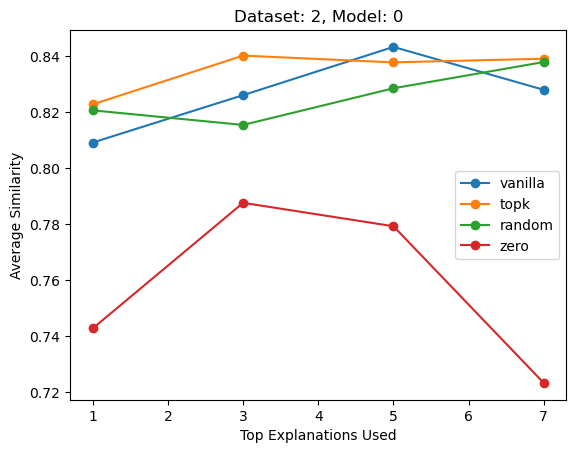

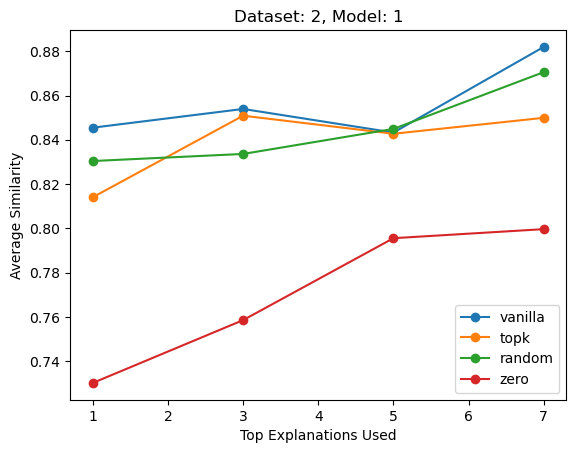

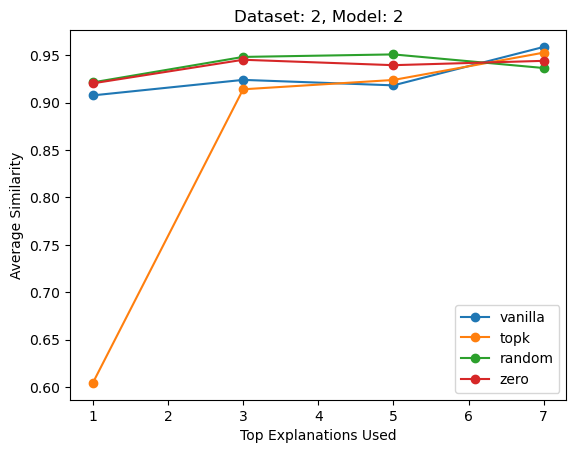

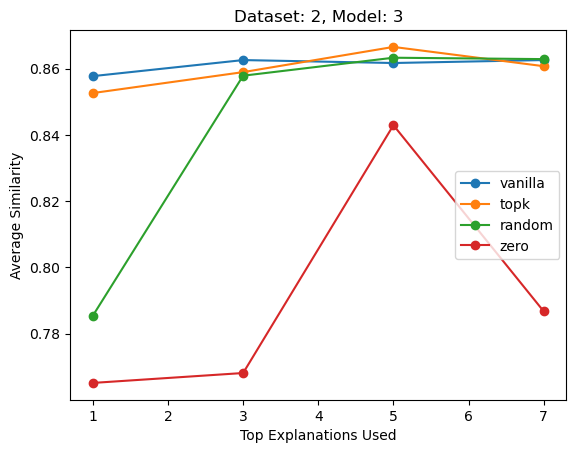

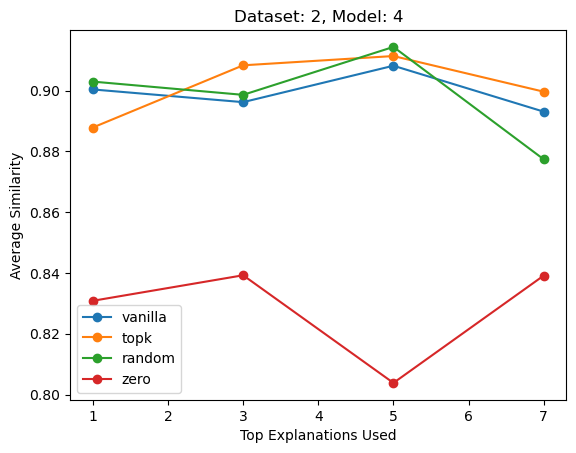

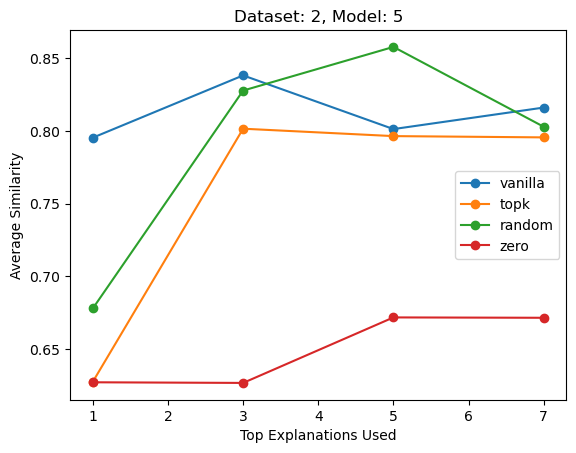

In [ ]:
# read saved results and visualize. Group by dataset and model, x axis is top_exp, y axis is average similarity, different lines for different explanation types
import numpy as np
import matplotlib.pyplot as plt 
which_dataset = 2    
explanation_types = ["vanilla", "topk", "random", "zero"]

for which_model in range(6):
    top_exps = [1,3, 5, 7]
    for etype in explanation_types:
        avg_similarities = []
        for top_exp in top_exps: #results are saved in "results" folder with this naming convention                  
            try:
                sims = np.load(f"results/results_dataset{which_dataset}_model{which_model}_topexp{top_exp}_etype{etype}.npy")
            except FileNotFoundError:
                avg_similarities.append(0)
                continue
            avg_similarities.append(np.mean(sims))
        plt.plot(top_exps, avg_similarities, marker='o', label=etype)
    plt.xlabel('Top Explanations Used')
    plt.ylabel('Average Similarity')
    plt.title(f'Dataset: {which_dataset}, Model: {which_model}')
    plt.legend()
    plt.show()

In [ ]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# Read results for dataset 1, grouped by model
# X-axis: top_exp values, Y-axis: average similarity, different lines for each explanation type

dataset_idx = 1
top_exps_to_read = [1, 3, 5, 7, 10]
explanation_types = ['vanilla', 'topk', 'random', 'zero', 'hybrid']

# Find all result files for dataset 1
pattern = f"results_dataset{dataset_idx}_model*_topexp*_etype*.npy"
files = glob.glob(pattern)
print(f"Found {len(files)} result files for dataset {dataset_idx}")

# Parse filenames to organize data
# data[model_idx][etype] = {top_exp: avg_similarity}
data = {}
available_etypes = set()
available_models = set()

rx = re.compile(r"results_dataset(\d+)_model(\d+)_topexp(\d+)_etype(.+)\.npy")
for fpath in files:
    fname = os.path.basename(fpath)
    m = rx.match(fname)
    if not m:
        continue
    _, model_s, topexp_s, etype = m.groups()
    model_idx = int(model_s)
    topexp = int(topexp_s)
    
    available_models.add(model_idx)
    available_etypes.add(etype)
    
    try:
        sims = np.load(fpath, allow_pickle=True)
        sims = np.asarray(sims).ravel()
        if len(sims) == 0:
            continue
        avg_sim = float(np.mean(sims))
        data.setdefault(model_idx, {}).setdefault(etype, {})[topexp] = avg_sim
    except Exception as e:
        print(f"Failed to load {fpath}: {e}")

if len(data) == 0:
    print("No data loaded.")
else:
    available_models_sorted = sorted(available_models)
    available_etypes_sorted = sorted(available_etypes)
    
    # Plot: one subplot per model
    n_models = len(available_models_sorted)
    n_cols = 2
    n_rows = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.ravel() if n_models > 1 else [axes]
    
    for idx, model_idx in enumerate(available_models_sorted):
        ax = axes[idx]
        for etype in available_etypes_sorted:
            sim_values = []
            topexp_values = []
            for te in top_exps_to_read:
                if te in data.get(model_idx, {}).get(etype, {}):
                    topexp_values.append(te)
                    sim_values.append(data[model_idx][etype][te])
            
            if len(sim_values) > 0:
                ax.plot(topexp_values, sim_values, marker='o', label=etype, linewidth=2)
        
        ax.set_xlabel('Top Explanations (top_exp)')
        ax.set_ylabel('Average Similarity')
        ax.set_title(f'Dataset {dataset_idx}, Model {model_idx}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAvailable explanation types: {sorted(available_etypes_sorted)}")
    print(f"Available models: {sorted(available_models_sorted)}")

Found 0 result files for dataset 1
No data loaded.


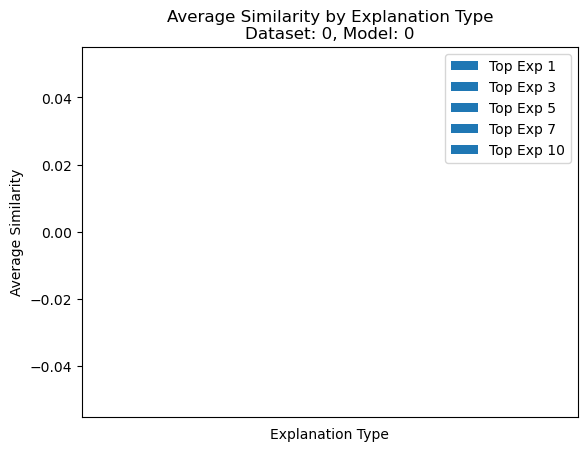

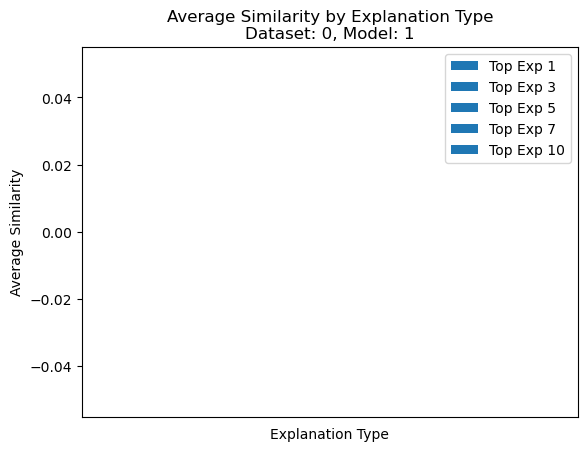

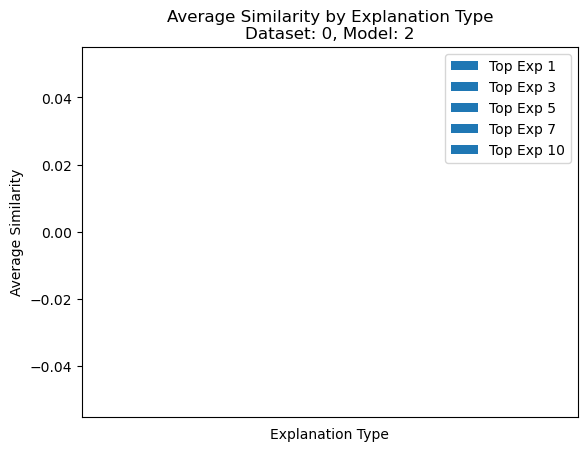

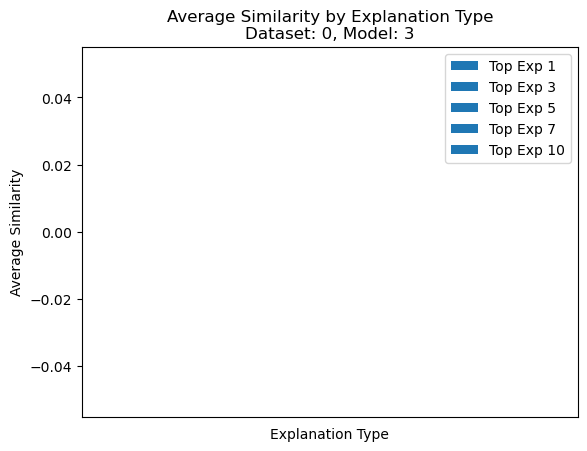

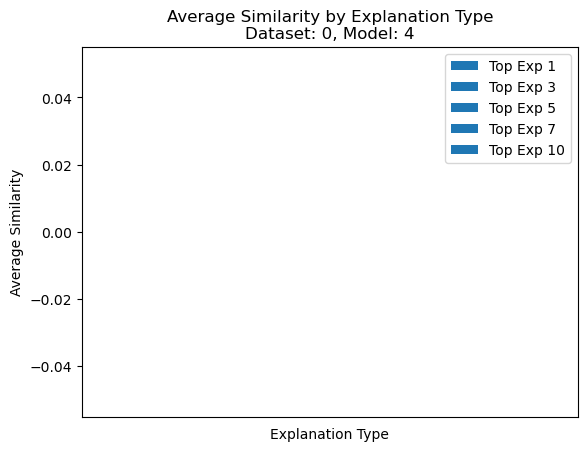

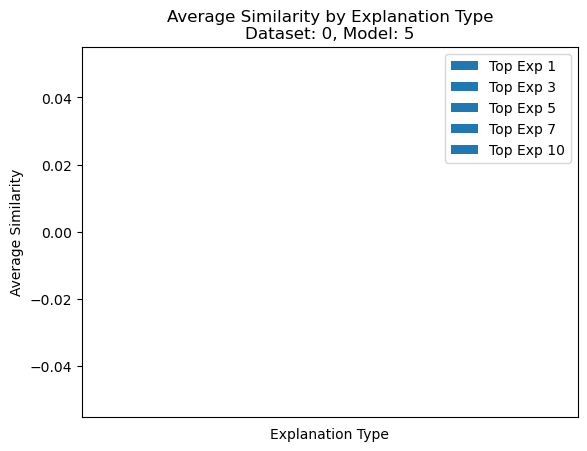

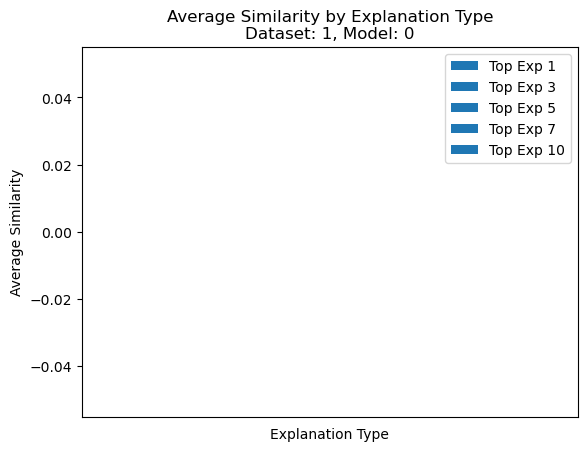

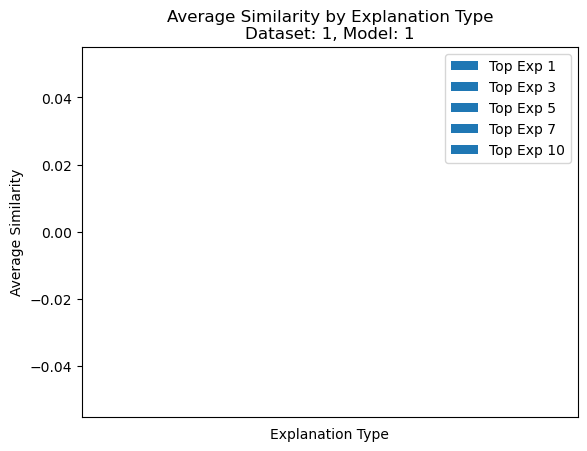

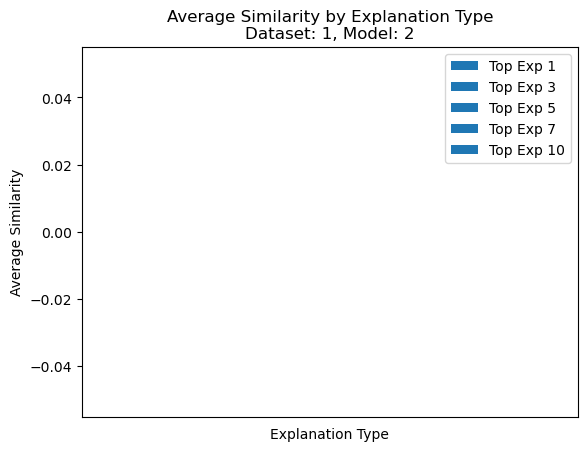

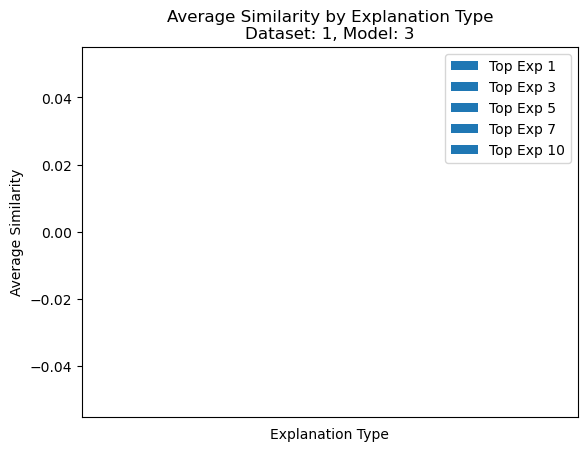

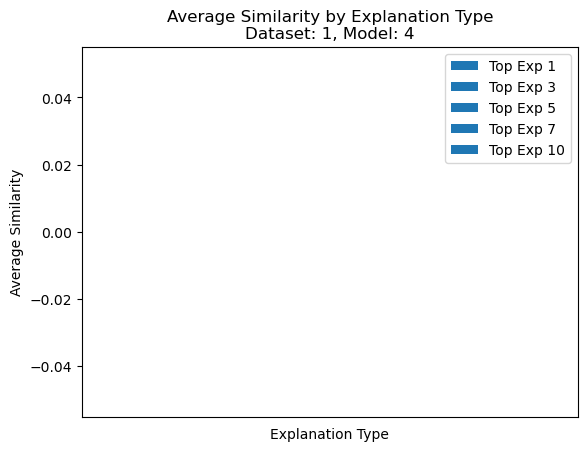

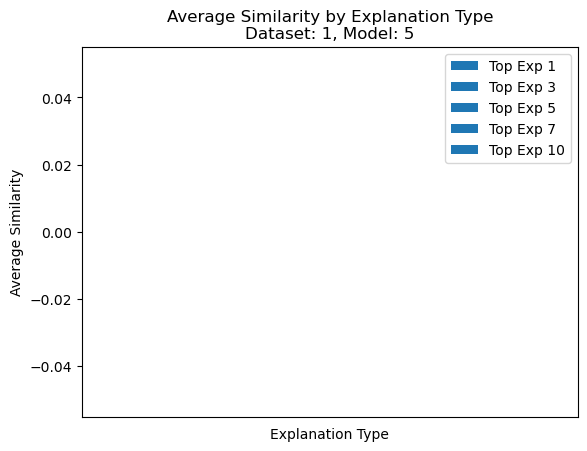

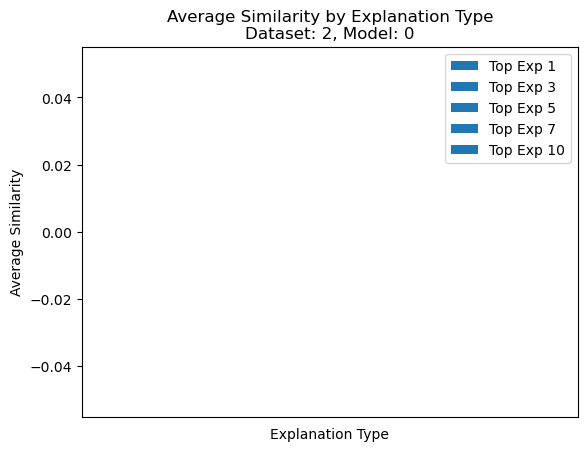

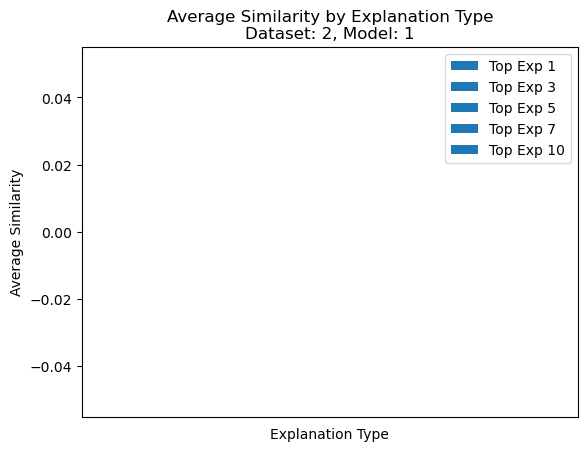

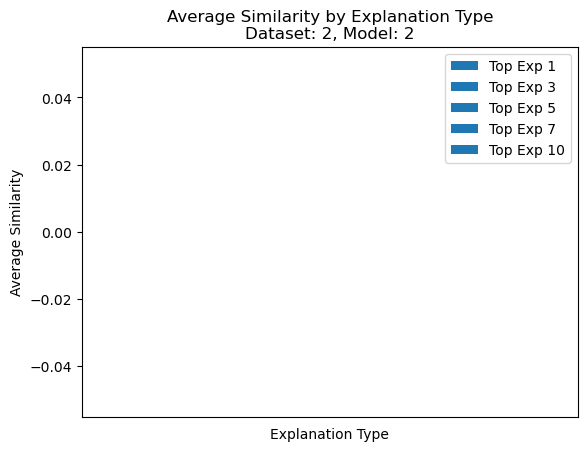

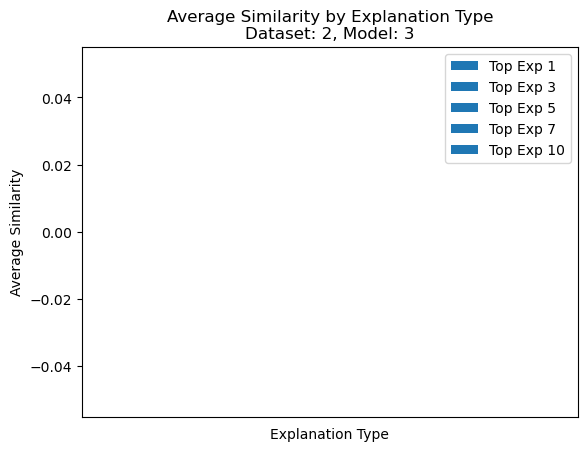

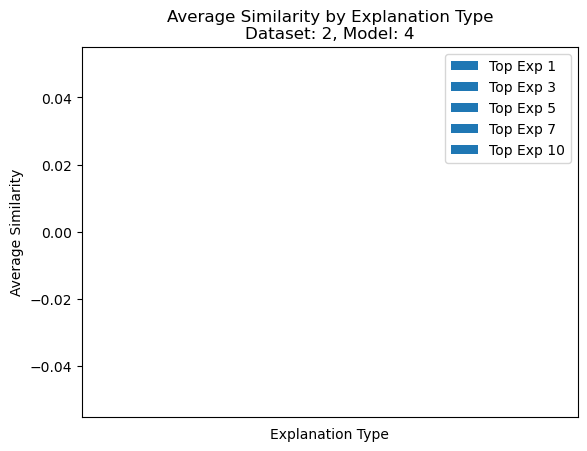

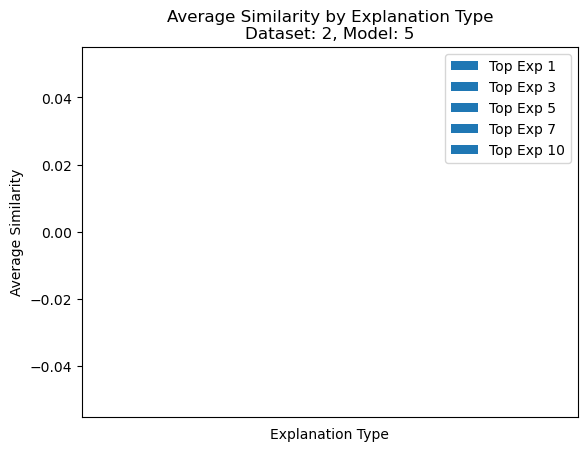

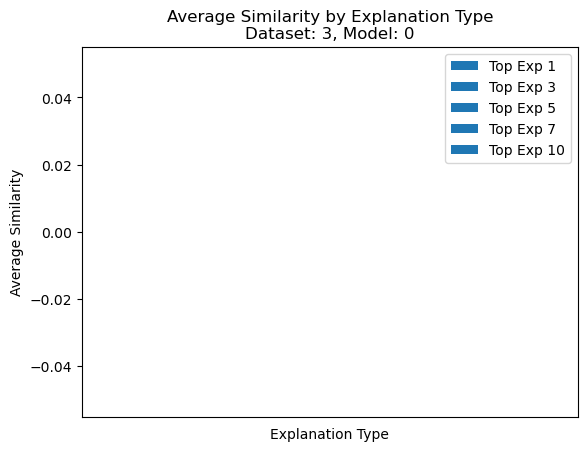

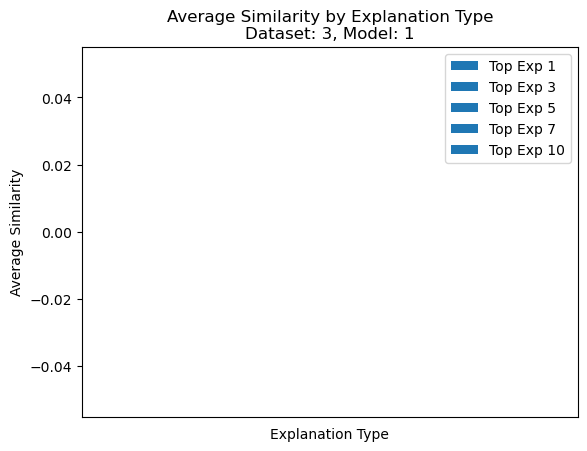

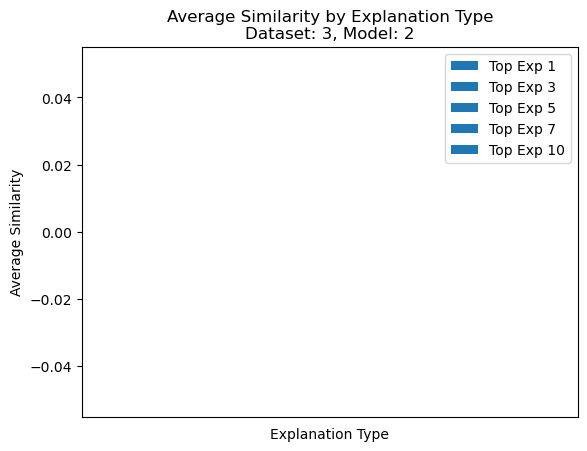

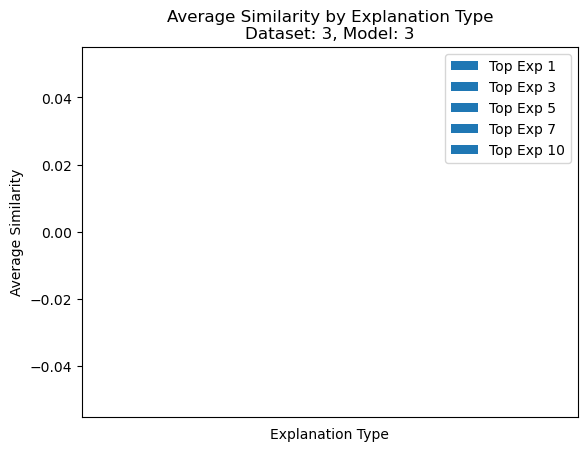

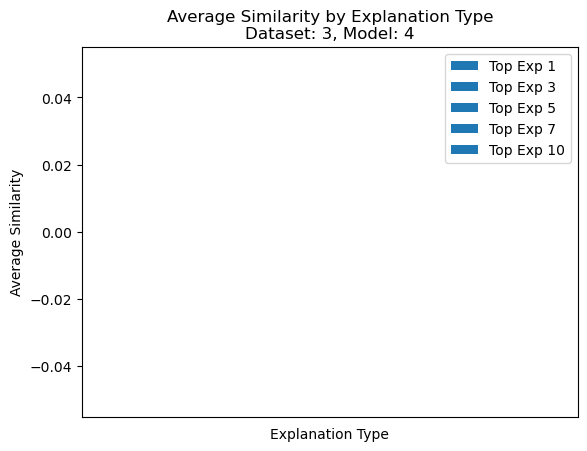

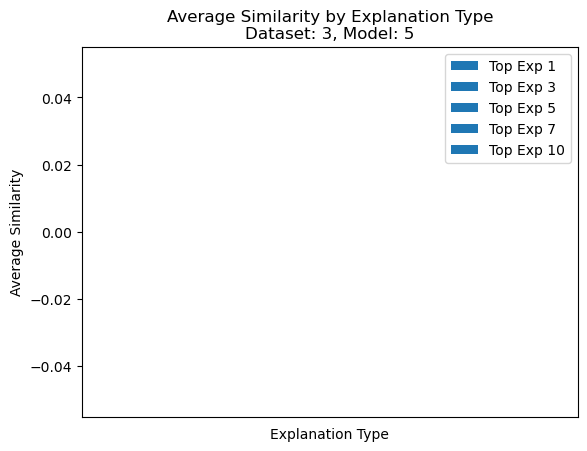

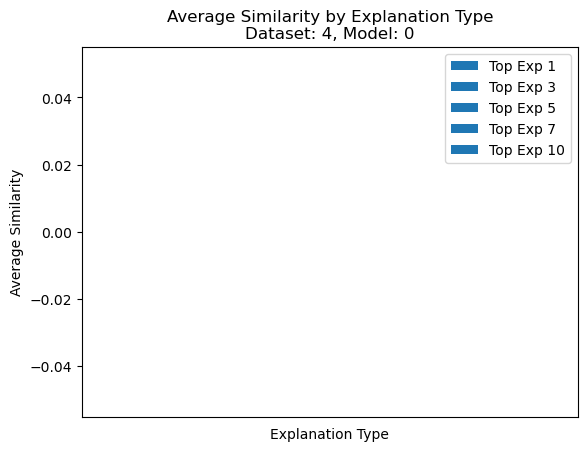

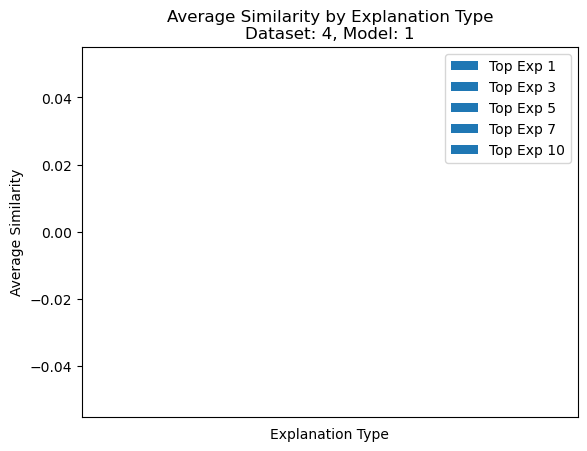

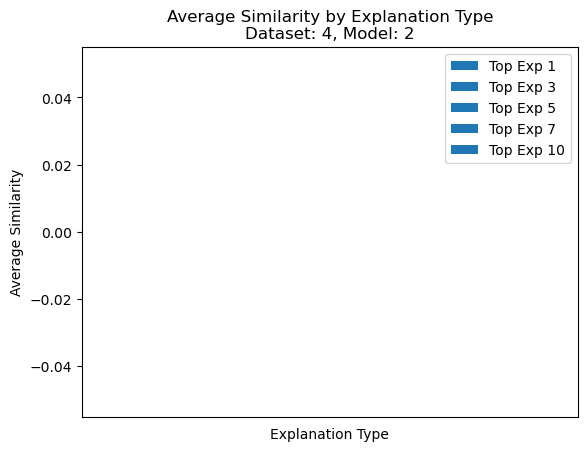

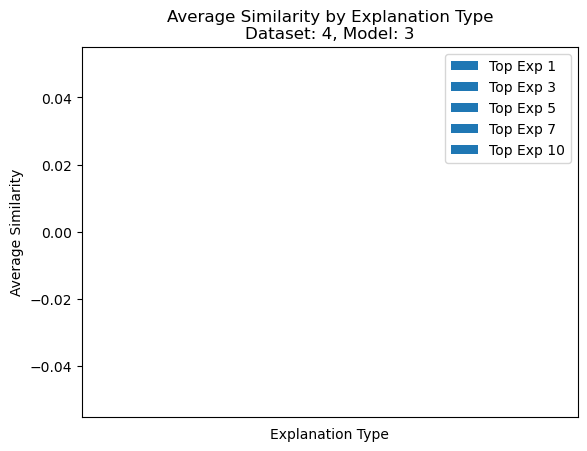

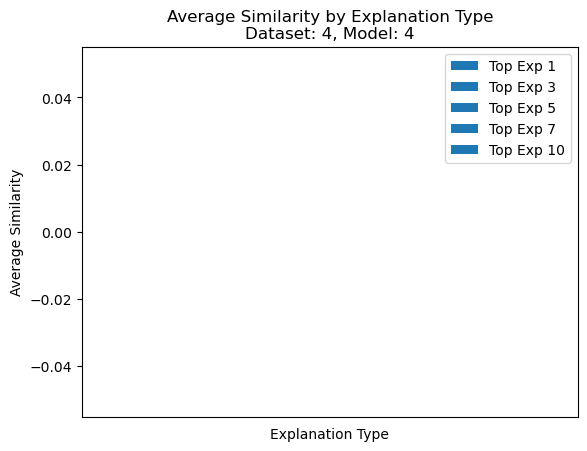

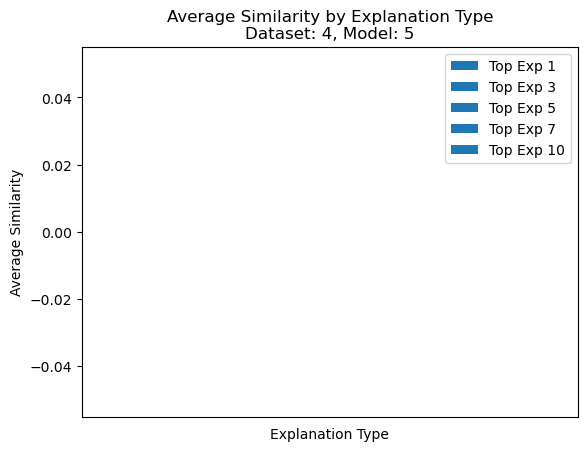

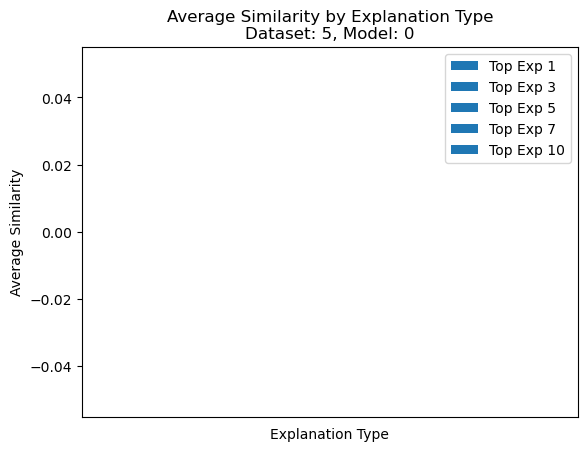

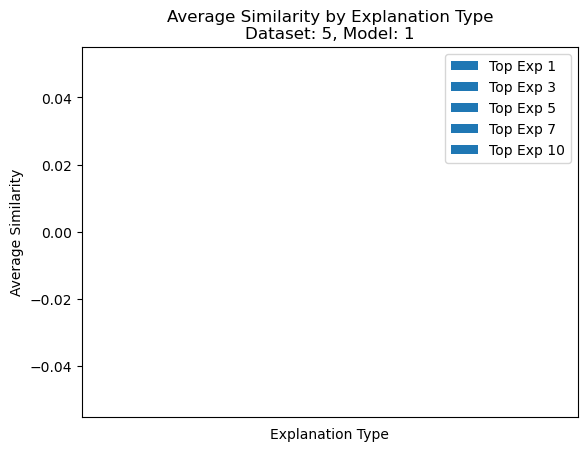

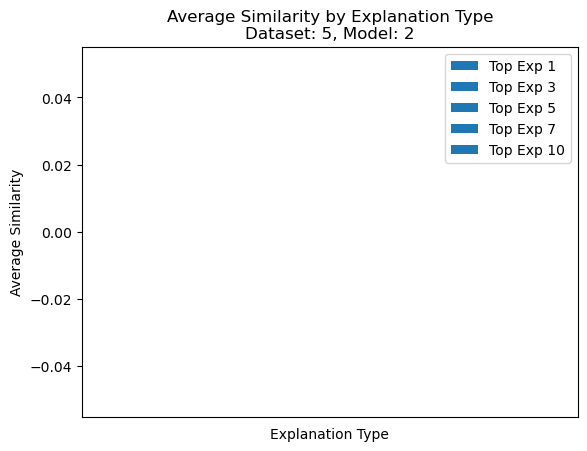

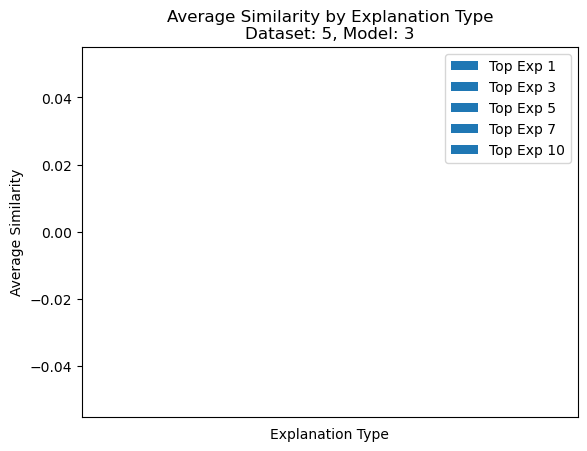

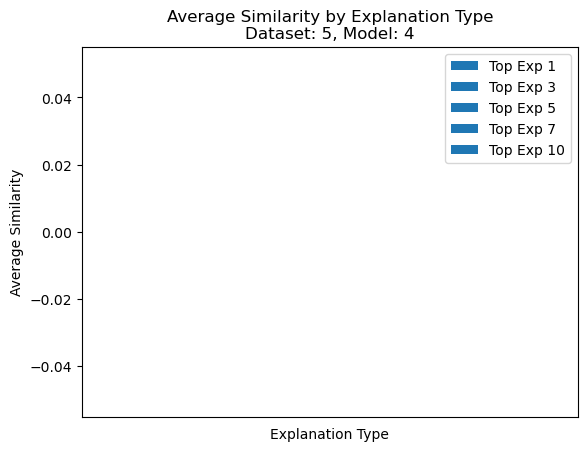

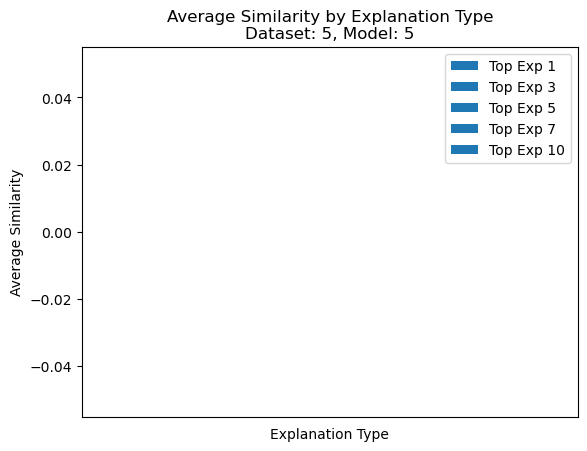

In [ ]:
#Visualize the saved results
import numpy as np
import matplotlib.pyplot as plt
for which_dataset in range(6):
    for which_model in range(6):
        top_exp_values = [1, 3, 5, 7, 10]
        explanation_types = []
        avg_similarities = {top_exp: [] for top_exp in top_exp_values}
        for top_exp in top_exp_values:
            for etype in ['vanilla', 'shap', 'lime']:
                try:
                    sims = np.load(f"results_dataset{which_dataset}_model{which_model}_topexp{top_exp}_etype{etype}.npy")
                    explanation_types.append(etype)
                    avg_similarities[top_exp].append(np.mean(sims))
                except FileNotFoundError:
                    continue
        #plotting
        x = np.arange(len(explanation_types))
        width = 0.15
        fig, ax = plt.subplots()
        for i, top_exp in enumerate(top_exp_values):
            ax.bar(x + i*width, avg_similarities[top_exp], width, label=f'Top Exp {top_exp}')
        ax.set_xlabel('Explanation Type')
        ax.set_ylabel('Average Similarity')
        ax.set_title(f'Average Similarity by Explanation Type\nDataset: {which_dataset}, Model: {which_model}')
        ax.set_xticks(x + width * (len(top_exp_values) - 1) / 2)
        ax.set_xticklabels(explanation_types)
        ax.legend()
        plt.show()

In [ ]:
# ...existing code...
def _flatten_and_stats(mat3d):
    """Convert nested list (dims x rows x cols) to numpy and return mean/std."""
    arr = np.array(mat3d, dtype=float)
    if arr.size == 0:
        return float('nan'), float('nan')
    return float(np.nanmean(arr)), float(np.nanstd(arr))


def sweep_top_exp(wd=which_dataset, wm=which_model, et=explanation_tool, hms=how_many_sets, sss=sample_set_sizes, nfe=nfe, ql=query_limit, so=False, top_exp_list=[1,3,5,10]):
    """
    Run run_attack_auto_v2 for each value in top_exp_list and return summary metrics.
    Returns dict: {top_exp: {'acc_mean':..., 'acc_std':..., 'sim_mean':..., 'sim_std':..., 'raw': (accuracies, sims)}}
    """
    results = {}
    for te in top_exp_list:
        print(f"\nRunning attack with top_exp = {te}")
        accs, sims, smega, other = run_attack_auto_v2(which_dataset, which_model, explanation_tool, how_many_sets, sample_set_sizes, nfe, query_limit, False, top_exp=te)
        acc_mean, acc_std = _flatten_and_stats(accs)
        sim_mean, sim_std = _flatten_and_stats(sims)
        results[te] = {
            'acc_mean': acc_mean,
            'acc_std': acc_std,
            'sim_mean': sim_mean,
            'sim_std': sim_std,
            'raw': (accs, sims, smega, other)
        }
        print(f"top_exp={te} -> acc_mean={acc_mean:.4f}, acc_std={acc_std:.4f}, sim_mean={sim_mean:.4f}, sim_std={sim_std:.4f}")
    return results
# ...existing code...

In [ ]:
# from attack_utils import sweep_top_exp
top_values = [1]
res = sweep_top_exp(top_exp_list=top_values)

In [ ]:
# Inspect results
print("\nSummary of results:")
print("TopExp\tAccMean\tSimMean\tSimStd")
for te, stats in res.items():
    print(te, stats['acc_mean'], stats['sim_mean'], stats['sim_std'])

In [ ]:
# write the results to results.txt file for later analysis add a header line
with open("results.txt", "a") as f:
    f.write("TopExp\tAccMean\tSimMean\n")
    for te, stats in res.items():
        f.write(f"{te}\t{stats['acc_mean']}\t{stats['sim_mean']}\n")